In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import concurrent.futures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
import math

In [2]:
# Load the dataset
data = pd.read_csv("RFLFSODataFull.csv")

In [3]:
# Important features
important_features = [
    'AbsoluteHumidity', 'AbsoluteHumidityMin', 'Distance', 'Frequency', 'ParticulateMax',
    'RainIntensity', 'RainIntensityMax', 'RainIntensityMin', 'RelativeHumidity',
    'SYNOPCode', 'Temperature', 'TemperatureDifference', 'TemperatureMax', 'Visibility'
]

In [4]:
smaller_data = data[important_features]

In [5]:
smaller_data.head()

,AbsoluteHumidity,AbsoluteHumidityMin,Distance,Frequency,ParticulateMax,RainIntensity,RainIntensityMax,RainIntensityMin,RelativeHumidity,SYNOPCode,Temperature,TemperatureDifference,TemperatureMax,Visibility
0,17.595709,17.340148,2115.338398,83500000000,0.0,0.0,0.0,0.0,71.974648,0,26.067846,13.63,26.603030,65884.51846
1,17.549693,17.299439,2113.999257,73500000000,0.0,0.0,0.0,0.0,73.502401,0,25.645703,-0.54,26.377164,64963.41092
2,17.290230,16.037894,2118.689047,83500000000,0.0,0.0,0.0,0.0,72.384543,0,25.653383,-0.24,27.670822,54794.28107
3,16.820880,15.895622,2114.632339,73500000000,0.0,0.0,0.0,0.0,70.447710,0,25.646271,-0.16,26.522100,50205.64159
4,16.813820,15.227225,2116.786055,83500000000,0.0,0.0,0.0,0.0,70.312385,0,25.673089,-0.10,26.305736,59038.32599


In [6]:
filtered_df = smaller_data.query('SYNOPCode == 9') # Checking which SYNOPCode as values. 
filtered_df

,AbsoluteHumidity,AbsoluteHumidityMin,Distance,Frequency,ParticulateMax,RainIntensity,RainIntensityMax,RainIntensityMin,RelativeHumidity,SYNOPCode,Temperature,TemperatureDifference,TemperatureMax,Visibility


In [34]:
# Randomly select 10,000 data points from the dataset
np.random.seed(42)  # For reproducibility
selected_data = smaller_data.sample(n=10000, random_state=42)

y_rand = data["RFL_Att"].sample(n=10000, random_state = 42)

In [31]:
np.shape(selected_data)

(10000, 14)

In [35]:
y = y_rand
X = selected_data

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# Display the shapes of the training and testing sets
(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

((8000, 14), (2000, 14), (8000,), (2000,))

In [38]:
# Initialize the model
linear_reg = LinearRegression()

In [39]:
# Train the model
linear_reg.fit(X_train, y_train)

LinearRegression()

In [40]:
# Predict on the test set
y_pred = linear_reg.predict(X_test)

In [64]:
# Evaluate the model
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [66]:
print(f'Root Mean Squared Error: {rmse}')
print(f'R^2 Score: {r2}')

Root Mean Squared Error: 2.354748135665252
R^2 Score: 0.5201653415172707


# Linear Regression for FSO

In [69]:
# Randomly select 10,000 data points from the dataset
np.random.seed(42)  # For reproducibility
selected_data = smaller_data.sample(n=10000, random_state=42)

y_FSO = data["FSO_Att"].sample(n=10000, random_state = 42)

In [70]:
y = y_FSO
X = selected_data

In [79]:
X_train, X_test, y_train_FSO, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
# Display the shapes of the training and testing sets
(X_train.shape, X_test.shape, y_train_FSO.shape, y_test.shape)

((8000, 14), (2000, 14), (8000,), (2000,))

In [81]:
# Initialize the model
linear_reg = LinearRegression()

In [82]:
# Train the model
linear_reg.fit(X_train, y_train)

LinearRegression()

In [83]:
# Predict on the test set
y_pred = linear_reg.predict(X_test)

In [84]:
# Evaluate the model
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [85]:
print(f'Root Mean Squared Error: {rmse}')
print(f'R^2 Score: {r2}')

Root Mean Squared Error: 3.1115307087914097
R^2 Score: 0.37543460865404277


# With Random Forest! 

In [43]:
# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [44]:
# Initialize the model
rf = RandomForestRegressor(random_state=42)

In [45]:
# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)


In [46]:
# Train the model
grid_search.fit(X_train, y_train) # Dataset too big to run all the data points. Lets reduce the data points.


Fitting 3 folds for each of 216 candidates, totalling 648 fits


C:\Users\Jitendra Sharma\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             verbose=2)

In [47]:
# Get the best parameters and the best estimator
best_params = grid_search.best_params_
best_rf = grid_search.best_estimator_

In [48]:
# Predict on the test set
y_pred_rf = best_rf.predict(X_test)

In [59]:
# Evaluate the model
rmse_rf = math.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf

0.7393429932478583

In [60]:
print(f'Best Parameters: {best_params}')
print(f'Root Mean Squared Error (Random Forest): {rmse_rf}')
print(f'R^2 Score (Random Forest): {r2_rf}')

Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Root Mean Squared Error (Random Forest): 0.7393429932478583
R^2 Score (Random Forest): 0.952696354289397


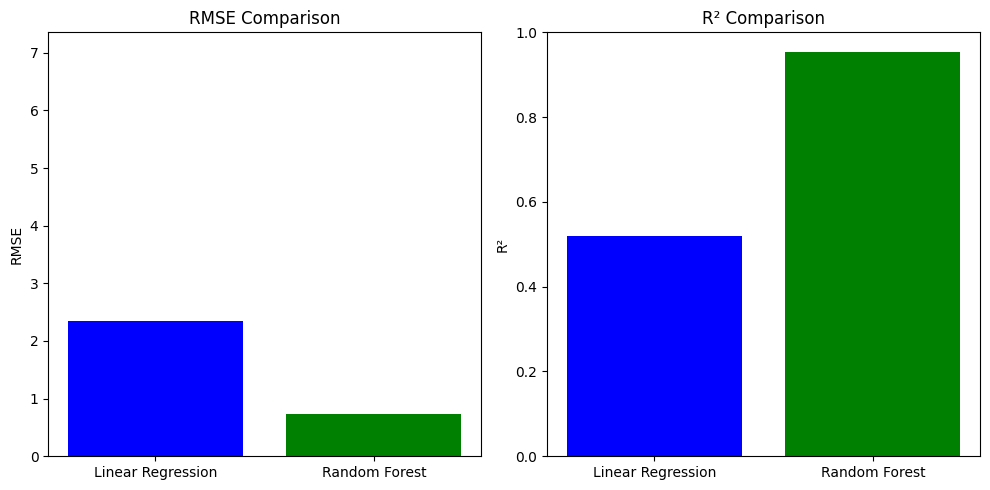

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Replace these values with your actual RMSE and R² results
rmse_values = {
    'Linear Regression': rmse,  # Example value
    'Random Forest': rmse_rf        # Example value
}

r2_values = {
    'Linear Regression': r2,  # Example value
    'Random Forest': r2_rf       # Example value
}

# Plotting the RMSE
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(rmse_values.keys(), rmse_values.values(), color=['blue', 'green'])
plt.title('RMSE Comparison')
plt.ylabel('RMSE')
plt.ylim(0, max(rmse_values.values()) + 5)

# Plotting the R²
plt.subplot(1, 2, 2)
plt.bar(r2_values.keys(), r2_values.values(), color=['blue', 'green'])
plt.title('R² Comparison')
plt.ylabel('R²')
plt.ylim(0, 1)  # R² values are generally between 0 and 1

plt.tight_layout()
plt.show()

# Random Forest for FSO

In [87]:
# Train the model
grid_search.fit(X_train, y_train_FSO) # Dataset too big to run all the data points. Lets reduce the data points.


Fitting 3 folds for each of 216 candidates, totalling 648 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             verbose=2)

In [88]:
# Get the best parameters and the best estimator
best_params_FSO = grid_search.best_params_
best_rf_FSO = grid_search.best_estimator_

In [89]:
# Predict on the test set
y_pred_rf_FSO = best_rf_FSO.predict(X_test)

In [90]:
rmse_rf = math.sqrt(mean_squared_error(y_test, y_pred_rf_FSO))
r2_rf = r2_score(y_test, y_pred_rf_FSO)
rmse_rf

1.293779891546806

In [91]:
print(f'Best Parameters: {best_params}')
print(f'Root Mean Squared Error (Random Forest): {rmse_rf}')
print(f'R^2 Score (Random Forest): {r2_rf}')

Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Root Mean Squared Error (Random Forest): 1.293779891546806
R^2 Score (Random Forest): 0.892018209132141
